<h1 style="color: red;">Phase 1&nbsp;: Chargement et exploration des données</h1>

In [1]:
import pandas as pd
import numpy as np
import glob
import json
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


<h3>Charger les fichiers JSON</h3>

In [2]:
# Chemins
attack_path = "../data/attack/*.json"
benign_path = "../data/benign/*.json"

attack_files = glob.glob(attack_path)
benign_files = glob.glob(benign_path)

len(attack_files), len(benign_files)


(233, 1)

<h3>Fonction de chargement JSON</h3>

In [3]:
def load_json_files(file_list, label):
    data = []
    for file in file_list:
        with open(file, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        record = json.loads(line)
                        record["label"] = label
                        data.append(record)
                    except json.JSONDecodeError:
                        continue
    return pd.DataFrame(data)


<h3>Créer les DataFrames</h3>

In [4]:
df_attack = load_json_files(attack_files, 1)
df_benign = load_json_files(benign_files, 0)

df = pd.concat([df_attack, df_benign], ignore_index=True)


<h3>Première inspection</h3>

In [5]:
df.shape


(1165012, 4)

In [6]:
df["label"].value_counts()


label
0    874923
1    290089
Name: count, dtype: int64

In [7]:
df.head()


,general,@timestamp,mqtt,label
0,"{'device_name': 'ard-w-01', 'application': 'We...",2025-01-16T14:20:11.418Z,"{'retained': False, 'qos': 0, 'message_value':...",1
1,"{'device_name': 'ard-w-01', 'application': 'We...",2025-01-16T14:20:11.419Z,"{'retained': False, 'qos': 0, 'message_value':...",1
2,"{'device_name': 'ard-w-01', 'application': 'We...",2025-01-16T14:20:11.419Z,"{'retained': False, 'qos': 0, 'message_value':...",1
3,"{'device_name': 'ard-w-15', 'application': 'Li...",2025-01-16T14:20:11.557Z,"{'retained': False, 'qos': 0, 'message_value':...",1
4,"{'device_name': 'ard-w-07', 'application': 'Ga...",2025-01-16T14:20:11.607Z,"{'retained': False, 'qos': 0, 'message_value':...",1


In [8]:
df.columns


Index(['general', '@timestamp', 'mqtt', 'label'], dtype='object')

<h3>Mini analyse visuelle</h3>

<H3>Distribution Attack vs Benign</H3>

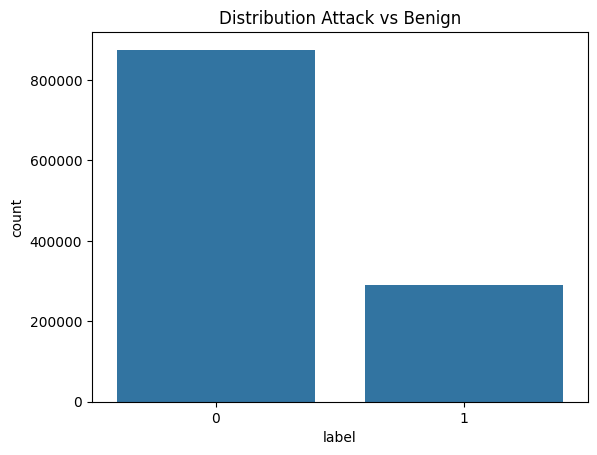

In [9]:
sns.countplot(x="label", data=df)
plt.title("Distribution Attack vs Benign")
plt.show()


<h3>Courbe temporelle — activité réseau (msg_per_sec)</h3>

But

Montrer :

trafic normal = stable

reconnaissance = rafales

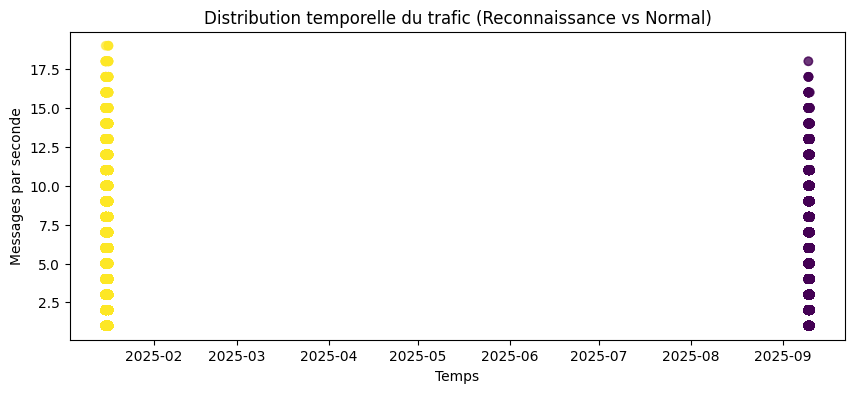

In [49]:
import matplotlib.pyplot as plt

# Échantillon pour éviter surcharge graphique
sample_df = df_clean.sample(50000, random_state=42)

plt.figure(figsize=(10,4))
plt.scatter(
    sample_df["@timestamp"],
    sample_df["msg_per_sec"],
    c=sample_df["label"],
    alpha=0.4
)
plt.xlabel("Temps")
plt.ylabel("Messages par seconde")
plt.title("Distribution temporelle du trafic (Reconnaissance vs Normal)")
plt.show()


<h3>Histogramme — distribution de msg_per_sec</h3>

But

Comparer quantitativement attaque vs normal.

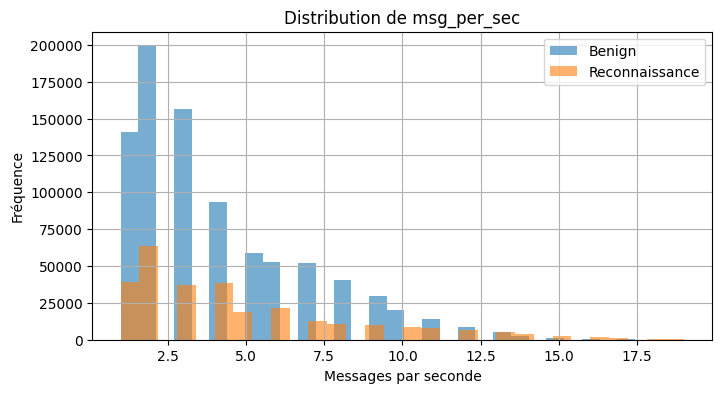

In [50]:
plt.figure(figsize=(8,4))

df_clean[df_clean["label"] == 0]["msg_per_sec"].hist(
    bins=30, alpha=0.6, label="Benign"
)
df_clean[df_clean["label"] == 1]["msg_per_sec"].hist(
    bins=30, alpha=0.6, label="Reconnaissance"
)

plt.xlabel("Messages par seconde")
plt.ylabel("Fréquence")
plt.title("Distribution de msg_per_sec")
plt.legend()
plt.show()


<H3>Heatmap de corrélation</H3>

In [55]:
corr_features_phase1 = [
    "msg_per_sec",
    "mqtt_qos",
    "mqtt_retained",
    "mqtt_duplicate",
    "label"
]


In [53]:
df_clean.columns


Index(['@timestamp', 'label', 'general_device_name', 'general_application',
       'general_ip', 'general_full_id', 'general_mac', 'mqtt_retained',
       'mqtt_qos', 'mqtt_message_value', 'mqtt_topic', 'mqtt_message_id',
       'mqtt_message_type', 'mqtt_duplicate', 'time_bin', 'msg_per_sec'],
      dtype='object')

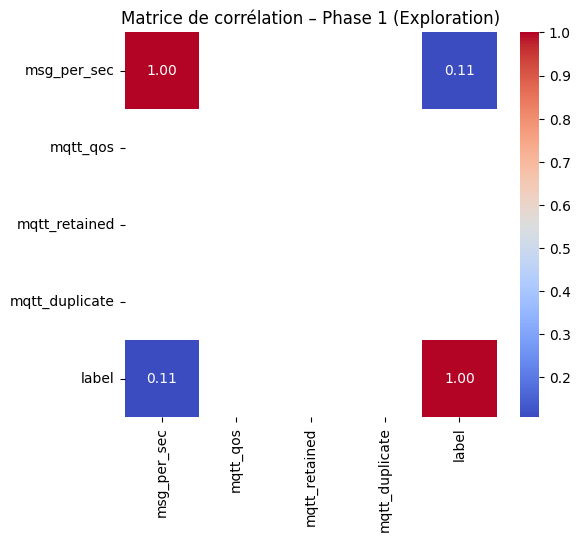

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = df_clean[corr_features_phase1].sample(50000, random_state=42)

corr_matrix = corr_df.corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matrice de corrélation – Phase 1 (Exploration)")
plt.show()


<H3>Boxplot par classe</H3>

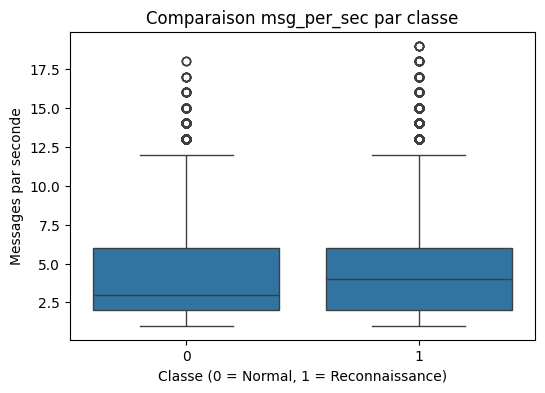

In [58]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="label",
    y="msg_per_sec",
    data=df_clean.sample(50000, random_state=42)
)
plt.xlabel("Classe (0 = Normal, 1 = Reconnaissance)")
plt.ylabel("Messages par seconde")
plt.title("Comparaison msg_per_sec par classe")
plt.show()


<h1 style="color: red;">Phase 2&nbsp;: Preparation</h1>

<h2>NETTOYAGE  </h2>

<H3>Suppression explicite des doublons</H3>

In [60]:
# Suppression des doublons basée sur une clé logique
initial_size = df_clean.shape[0]

df_clean = df_clean.drop_duplicates(
    subset=["@timestamp", "general_device_name", "mqtt_topic"]
)

final_size = df_clean.shape[0]

print(f"Doublons supprimés : {initial_size - final_size}")


Doublons supprimés : 9036


<H3>Nettoyage des valeurs manquantes
</H3>

In [62]:
# 🔹 Nettoyage des valeurs manquantes
# Remplacer toutes les valeurs NaN par 0
features_df = features_df.fillna(0)

# Vérification rapide
print("Aperçu après nettoyage :")
print(features_df.head())

# Vérifier s'il reste des valeurs manquantes
print("\nNombre de valeurs manquantes par colonne :")
print(features_df.isna().sum())


Aperçu après nettoyage :
  general_device_name                @timestamp  msg_per_sec  topic_count  \
0            ard-w-01 2025-01-15 13:04:56+00:00            2            1   
1            ard-w-01 2025-01-15 13:04:57+00:00           14            7   
2            ard-w-01 2025-01-15 13:04:58+00:00            5            3   
3            ard-w-01 2025-01-15 13:04:59+00:00            6            6   
4            ard-w-01 2025-01-15 13:05:00+00:00            2            2   

   ratio_retained  ip_count  mac_count  mqtt_qos  mqtt_duplicate  label  \
0             0.0         1          1       0.0             0.0      1   
1             0.0         1          1       0.0             0.0      1   
2             0.0         1          1       0.0             0.0      1   
3             0.0         1          1       0.0             0.0      1   
4             0.0         1          1       0.0             0.0      1   

   topic_entropy  timestamp_diff  
0  -1.442695e-09          

<h3>Synchroniser les capteurs et paquets réseau</h3>

In [65]:
df["@timestamp"] = pd.to_datetime(df["@timestamp"])
df = df.sort_values("@timestamp")

# Si on a plusieurs capteurs pour un même device à la même seconde, on peut les agréger
df_clean = df_clean.groupby(['general_device_name', pd.Grouper(key='@timestamp', freq='1s')]).agg({
    'mqtt_message_value': 'count',       # nombre de messages par seconde
    'mqtt_topic': lambda x: list(x),     # liste des topics
    'general_ip': 'first',
    'general_mac': 'first',
    'mqtt_retained': 'mean',
    'mqtt_qos': 'mean',
    'mqtt_duplicate': 'mean',
    'label': 'max'                       # label du plus "malveillant" si conflit
}).reset_index()


In [11]:
df["@timestamp"].min(), df["@timestamp"].max()


(Timestamp('2025-01-15 13:04:56.048000+0000', tz='UTC'),
 Timestamp('2025-09-10 02:09:39.932000+0000', tz='UTC'))

<h3>Fenêtres temporelles</h3>

In [66]:
# Création d'une colonne time_bin à la seconde
df_clean['time_bin'] = df_clean['@timestamp'].dt.floor('1s')

# Exemple : on peut faire une fenêtre glissante de 5 secondes pour certaines features
window_size = 5  # secondes

df_clean['msg_per_sec_rolling'] = df_clean.groupby('general_device_name')['mqtt_message_value']\
                                         .transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())


Dans dataset, certaines colonnes (general_application, general_full_id, mqtt_topic, mqtt_message_value, etc.) sont des objets complexes ou des listes.
Pour que Random Forest ou n’importe quel modèle ML classique puisse les utiliser, il faut que les features soient numériques et scalaires.

Exemple :

mqtt_message_value peut être un nombre (137.0), une liste ([159.0, 288.0, 252.0]) ou un string ("Portrait Up").

mqtt_topic peut être une liste de topics par seconde.

Si tu ne “aplatis” pas :

RandomForest ne pourra pas traiter les listes / objets → erreurs.

L’agrégation (moyenne, entropie, counts) devient compliquée.

<b>Aplatir</b> = nécessaire pour que toutes les features soient numériques et scalaires.

<h3>Aplatir general</h3>

In [12]:
general_df = pd.json_normalize(df["general"])
general_df.columns = [f"general_{c}" for c in general_df.columns]


<h3>Aplatir mqtt</h3>

In [13]:
mqtt_df = pd.json_normalize(df["mqtt"])
mqtt_df.columns = [f"mqtt_{c}" for c in mqtt_df.columns]


In [69]:
# Vérifier si plusieurs messages par device par time_bin
duplicates = df_clean.groupby(['general_device_name', 'time_bin']).size()
print(duplicates[duplicates > 1])


Series([], dtype: int64)


In [70]:
df_clean.head()


,general_device_name,@timestamp,mqtt_message_value,mqtt_topic,general_ip,general_mac,mqtt_retained,mqtt_qos,mqtt_duplicate,label,time_bin,msg_per_sec_rolling
0,ard-w-01,2025-01-15 13:04:56+00:00,2,"[iiot/weather/temp, iiot/weather/temp]",192.168.1.10,08:B6:1F:82:12:30,0.0,0.0,0.0,1,2025-01-15 13:04:56+00:00,2.000000
1,ard-w-01,2025-01-15 13:04:57+00:00,14,"[iiot/weather/humidity, iiot/weather/humidity,...",192.168.1.10,08:B6:1F:82:12:30,0.0,0.0,0.0,1,2025-01-15 13:04:57+00:00,8.000000
2,ard-w-01,2025-01-15 13:04:58+00:00,4,"[iiot/weather/bmp180/temp, iiot/weather/linear...",192.168.1.10,08:B6:1F:82:12:30,0.0,0.0,0.0,1,2025-01-15 13:04:58+00:00,6.666667
3,ard-w-01,2025-01-15 13:04:59+00:00,6,"[iiot/weather/temp, iiot/weather/humidity, iio...",192.168.1.10,08:B6:1F:82:12:30,0.0,0.0,0.0,1,2025-01-15 13:04:59+00:00,6.500000
4,ard-w-01,2025-01-15 13:05:00+00:00,2,"[iiot/weather/lineartemp, iiot/weather/temp]",192.168.1.10,08:B6:1F:82:12:30,0.0,0.0,0.0,1,2025-01-15 13:05:00+00:00,5.600000


In [71]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 464548 entries, 0 to 464547
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   general_device_name  464548 non-null  object             
 1   @timestamp           464548 non-null  datetime64[ns, UTC]
 2   mqtt_message_value   464548 non-null  int64              
 3   mqtt_topic           464548 non-null  object             
 4   general_ip           464548 non-null  object             
 5   general_mac          464548 non-null  object             
 6   mqtt_retained        464548 non-null  float64            
 7   mqtt_qos             464548 non-null  float64            
 8   mqtt_duplicate       464548 non-null  float64            
 9   label                464548 non-null  int64              
 10  time_bin             464548 non-null  datetime64[ns, UTC]
 11  msg_per_sec_rolling  464548 non-null  float64            
dtypes:

<h5><b>Pourquoi ?</b></h5>

La reconnaissance = rafales, scans, rythmes anormaux.

In [17]:
df_clean["time_bin"] = df_clean["@timestamp"].dt.floor("1s")


<h1 style="color: red;">Phase 3&nbsp;: Feature Engineering</h1> 

<h3>Extraire des statistiques</h3>
On extrait : moyenne, écart-type, entropie, fréquence dominante, messages par seconde.

In [72]:
# Assurez-vous que '@timestamp' est en datetime
df_clean['@timestamp'] = pd.to_datetime(df_clean['@timestamp'])

# Créer une fenêtre temporelle 1s
df_clean['time_bin'] = df_clean['@timestamp'].dt.floor('1s')

# Tri
df_clean = df_clean.sort_values(['general_device_name', 'time_bin'])

# Moyenne / fréquence : messages par seconde
df_clean['msg_per_sec'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_message_value'].transform('count')

# Écart-type des messages par fenêtre
df_clean['msg_std'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_message_value'].transform('std').fillna(0)

# Entropie des topics
def shannon_entropy(x):
    probs = x.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs + 1e-9))

df_clean['topic_entropy'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_topic'].transform(shannon_entropy)

# Fréquence dominante d'un topic
def dominant_topic_freq(x):
    if len(x) == 0:
        return 0
    counts = x.value_counts()
    return counts.iloc[0] / len(x)

df_clean['dominant_topic_freq'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_topic'].transform(dominant_topic_freq)


<h3>indicateurs réseau</h3>
On inclut : qos, retained, duplicate, nb de topics, nb d’IP, nb de MAC.

In [75]:
# QoS moyen
df_clean['mqtt_qos_mean'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_qos'].transform('mean')

# Ratio messages retained
df_clean['ratio_retained'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_retained'].transform('mean')

# Ratio messages duplicates
df_clean['ratio_duplicate'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_duplicate'].transform('mean')

# Convertir en string si c'est une liste
df_clean['mqtt_topic'] = df_clean['mqtt_topic'].apply(lambda x: str(x) if isinstance(x, list) else x)

# Nombre de topics uniques
df_clean['topic_count'] = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_topic'].transform('nunique')

# Nombre d'IP uniques
df_clean['ip_count'] = df_clean.groupby(['general_device_name', 'time_bin'])['general_ip'].transform('nunique')

# Nombre de MAC uniques
df_clean['mac_count'] = df_clean.groupby(['general_device_name', 'time_bin'])['general_mac'].transform('nunique')


<h3>Sélection des features</h3>

a) Chi² (pour features catégorielles ou discrètes)

In [77]:
from sklearn.feature_selection import SelectKBest, chi2

# Exemple : on prend uniquement les features numériques non-continues
X_chi2 = df_clean[['msg_per_sec', 'topic_count', 'ip_count', 'mac_count']].fillna(0)
y_chi2 = df_clean['label']

chi2_selector = SelectKBest(chi2, k='all')
chi2_selector.fit(X_chi2, y_chi2)
print("Chi2 Scores : ", chi2_selector.scores_)


Chi2 Scores :  [0. 0. 0. 0.]


b) ANOVA F-test (pour features continues)

In [78]:
from sklearn.feature_selection import f_classif

X_anova = df_clean[['msg_per_sec', 'msg_std', 'topic_entropy', 'dominant_topic_freq', 'mqtt_qos_mean']].fillna(0)
y_anova = df_clean['label']

anova_selector = f_classif(X_anova, y_anova)
print("ANOVA F-scores : ", anova_selector[0])


ANOVA F-scores :  [nan nan  0. nan nan]


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [0 1 3 4] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


c) PCA (réduction de dimension)

In [79]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_pca = df_clean[['msg_per_sec', 'msg_std', 'topic_entropy', 'dominant_topic_freq', 
                  'mqtt_qos_mean', 'ratio_retained', 'ratio_duplicate', 
                  'topic_count', 'ip_count', 'mac_count']].fillna(0)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# PCA pour réduire à 5 composantes
pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_scaled)
print("Explained variance ratio :", pca.explained_variance_ratio_)


Explained variance ratio : [nan nan nan nan nan]


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\decomposition\_pca.py:646: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


In [84]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, chi2

# -----------------------------
# 1️⃣ Regrouper les timestamps
# -----------------------------
df_clean['time_bin'] = df_clean['@timestamp'].dt.floor('5s')  # fenêtre de 5 secondes

# -----------------------------
# 2️⃣ Calcul des features par device et par fenêtre
# -----------------------------
def shannon_entropy(x):
    probs = x.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs + 1e-9))

agg_dict = {
    'mqtt_message_value': 'count',           # msg_per_sec
    'mqtt_topic': ['nunique', shannon_entropy],  # topic_count, topic_entropy
    'mqtt_retained': 'mean',                 # ratio_retained
    'mqtt_qos': 'mean',                       # mqtt_qos_mean
    'mqtt_duplicate': 'mean',                 # ratio_duplicate
    'general_ip': 'nunique',                  # ip_count
    'general_mac': 'nunique'                  # mac_count
}

features_df = df_clean.groupby(['general_device_name', 'time_bin']).agg(agg_dict)

# Aplatir le multi-index des colonnes
features_df.columns = ['msg_per_sec', 'topic_count', 'topic_entropy',
                       'ratio_retained', 'mqtt_qos_mean', 'ratio_duplicate',
                       'ip_count', 'mac_count']

# Calcul de la fréquence dominante des topics
dominant_topic_freq = df_clean.groupby(['general_device_name', 'time_bin'])['mqtt_topic']\
                              .apply(lambda x: x.value_counts().max() / len(x))
features_df['dominant_topic_freq'] = dominant_topic_freq

# Ajout d'une feature comportementale : écart entre messages successifs
df_clean = df_clean.sort_values(['general_device_name', '@timestamp'])
df_clean['timestamp_diff'] = df_clean.groupby('general_device_name')['@timestamp']\
                                     .diff().dt.total_seconds().fillna(0)
timestamp_diff_mean = df_clean.groupby(['general_device_name', 'time_bin'])['timestamp_diff'].mean()
features_df['timestamp_diff'] = timestamp_diff_mean

# Remplacer les NaN par 0
features_df.fillna(0, inplace=True)

# -----------------------------
# 3️⃣ Sélection des features avec variance
# -----------------------------
X = features_df[['msg_per_sec', 'topic_count', 'topic_entropy',
                 'ratio_retained', 'mqtt_qos_mean', 'ratio_duplicate',
                 'ip_count', 'mac_count', 'dominant_topic_freq', 'timestamp_diff']]

selector = VarianceThreshold(threshold=1e-5)
X_var = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
print("Features conservées (variance > 1e-5) :", selected_features)

# -----------------------------
# 4️⃣ Chi² pour features discrètes
# -----------------------------
# Exemple : utiliser 'msg_per_sec', 'topic_count', 'dominant_topic_freq'
X_chi = X_var[:, [0, 1, 3]]  # colonnes discrètes
y = df_clean.groupby(['general_device_name', 'time_bin'])['label'].max().values  # label par fenêtre
chi_scores, p_values = chi2(X_chi, y)
print("Chi² scores :", chi_scores)

# -----------------------------
# 5️⃣ PCA pour réduction de dimension
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)

pca = PCA(n_components=5)
X_reduced = pca.fit_transform(X_scaled)
print("Explained variance ratio :", pca.explained_variance_ratio_)

# -----------------------------
# ✅ Résultat final
# -----------------------------
print("Shape features après PCA :", X_reduced.shape)


Features conservées (variance > 1e-5) : Index(['msg_per_sec', 'topic_count', 'topic_entropy', 'dominant_topic_freq',
       'timestamp_diff'],
      dtype='object')
Chi² scores : [337.84280003 826.80320995  18.18905006]
Explained variance ratio : [0.71737346 0.19999655 0.07036444 0.01138219 0.00088336]
Shape features après PCA : (133640, 5)


<h1 style="color: red;">Phase 4&nbsp;: Modélisation</h1> 

<h3>Préparation des données</h3>

In [85]:
from sklearn.model_selection import train_test_split

# X_reduced : features après PCA ou X_var pour features conservées
# y : labels par fenêtre
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test :", X_test.shape)


Shape X_train: (106912, 5)
Shape X_test : (26728, 5)


<h3>Machine Learning</h3>

<h3>Random Forest</h3>

In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("===== Random Forest Classification Report =====")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC RF:", roc_auc_score(y_test, y_proba_rf))


===== Random Forest Classification Report =====
              precision    recall  f1-score   support

           0       0.89      0.62      0.73     20226
           1       0.39      0.77      0.52      6502

    accuracy                           0.65     26728
   macro avg       0.64      0.69      0.62     26728
weighted avg       0.77      0.65      0.68     26728

ROC-AUC RF: 0.7637841384967522


<h3>Decision Tree</h3>

In [88]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:,1]

print("===== Decision Tree Classification Report =====")
print(classification_report(y_test, y_pred_dt))

roc_dt = roc_auc_score(y_test, y_proba_dt)
print("ROC-AUC DT:", roc_dt)


===== Decision Tree Classification Report =====
              precision    recall  f1-score   support

           0       0.80      0.96      0.87     20226
           1       0.67      0.24      0.35      6502

    accuracy                           0.79     26728
   macro avg       0.74      0.60      0.61     26728
weighted avg       0.77      0.79      0.75     26728

ROC-AUC DT: 0.7578501239591509


<h3>SVM (avec StandardScaler si pas déjà normalisé)</h3>

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

# ------------------------------
# Réduire taille pour SVM
# ------------------------------
# exemple : 20 000 échantillons
X_small, _, y_small, _ = train_test_split(
    X_reduced, y,
    train_size=5000,
    stratify=y,
    random_state=42
)

# Séparer en train/test (80/20)
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=42
)

print("Shape X_train_svm:", X_train_svm.shape)
print("Shape X_test_svm :", X_test_svm.shape)

# ------------------------------
# Entraînement SVM
# ------------------------------
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train_svm, y_train_svm)

# Prédictions
y_pred_svm = svm.predict(X_test_svm)
y_proba_svm = svm.predict_proba(X_test_svm)[:,1]

# Résultats
print("===== SVM Classification Report (sous-échantillon) =====")
print(classification_report(y_test_svm, y_pred_svm))

roc_svm = roc_auc_score(y_test_svm, y_proba_svm)
print("ROC-AUC SVM (sous-échantillon) :", roc_svm)


Shape X_train_svm: (4000, 5)
Shape X_test_svm : (1000, 5)
===== SVM Classification Report (sous-échantillon) =====
              precision    recall  f1-score   support

           0       0.76      1.00      0.86       757
           1       0.00      0.00      0.00       243

    accuracy                           0.76      1000
   macro avg       0.38      0.50      0.43      1000
weighted avg       0.57      0.76      0.65      1000

ROC-AUC SVM (sous-échantillon) : 0.4425091464574805


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

<h3>XGBoost</h3>

In [98]:
from xgboost import XGBClassifier
# calcul poids de la classe minoritaire
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

print("===== XGBoost Classification Report =====")
print(classification_report(y_test, y_pred_xgb))

roc_xgb = roc_auc_score(y_test, y_proba_xgb)
print("ROC-AUC XGB:", roc_xgb)


===== XGBoost Classification Report =====
              precision    recall  f1-score   support

           0       0.89      0.62      0.73     20226
           1       0.39      0.76      0.52      6502

    accuracy                           0.65     26728
   macro avg       0.64      0.69      0.62     26728
weighted avg       0.77      0.65      0.68     26728

ROC-AUC XGB: 0.7614784373065444


<H3>Comparer les performances</H3>

In [99]:
results = {
    'Random Forest': roc_rf,
    'Decision Tree': roc_dt,
    'SVM': roc_svm,
    'XGBoost': roc_xgb
}
print("ROC-AUC comparatif :", results)


ROC-AUC comparatif : {'Random Forest': 0.7624582376025717, 'Decision Tree': 0.7578501239591509, 'SVM': 0.4425091464574805, 'XGBoost': 0.7614784373065444}


<h3>Deep Learning (LSTM & CNN1D)</h3>

<h5>a) Préparer les séquences temporelles</h5>

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

# reshape pour DL : (samples, timesteps, features)
# ici timesteps=10 secondes
timesteps = 10
n_features = X_train.shape[1]

def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i+timesteps])
        y_seq.append(y[i+timesteps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, timesteps)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, timesteps)
print(type(y_train))
print(type(y_test))


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [106]:
print("X_train_seq:", X_train_seq.shape)
print("y_train_seq:", y_train_seq.shape)
print("X_test_seq :", X_test_seq.shape)
print("y_test_seq :", y_test_seq.shape)


X_train_seq: (106902, 10, 5)
y_train_seq: (106902,)
X_test_seq : (26718, 10, 5)
y_test_seq : (26718,)


<h5>b) LSTM</h5>

In [107]:
lstm_model = Sequential([
    LSTM(64, input_shape=(timesteps, n_features)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, validation_split=0.1)

# prédictions
y_proba_lstm = lstm_model.predict(X_test_seq).flatten()
y_pred_lstm = (y_proba_lstm > 0.5).astype(int)

print("===== LSTM Classification Report =====")
print(classification_report(y_test_seq, y_pred_lstm))
print("ROC-AUC LSTM:", roc_auc_score(y_test_seq, y_proba_lstm))


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.7561 - loss: 0.5578 - val_accuracy: 0.7560 - val_loss: 0.5589
Epoch 2/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7568 - loss: 0.5553 - val_accuracy: 0.7560 - val_loss: 0.5559
Epoch 3/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7568 - loss: 0.5551 - val_accuracy: 0.7560 - val_loss: 0.5575
Epoch 4/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7568 - loss: 0.5551 - val_accuracy: 0.7560 - val_loss: 0.5561
Epoch 5/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7568 - loss: 0.5550 - val_accuracy: 0.7560 - val_loss: 0.5562
Epoch 6/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.7568 - loss: 0.5551 - val_accuracy: 0.7560 - val_loss: 0.5574
Epoch 7/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7568 - loss: 0.5550 - val_accuracy: 0.7560 - val_loss: 0.5560
Epoch 8/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.7568 -

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

<H5>c) CNN 1D</H5>

In [108]:
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(timesteps, n_features)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, validation_split=0.1)

# prédictions
y_proba_cnn = cnn_model.predict(X_test_seq).flatten()
y_pred_cnn = (y_proba_cnn > 0.5).astype(int)

print("===== CNN 1D Classification Report =====")
print(classification_report(y_test_seq, y_pred_cnn))
print("ROC-AUC CNN:", roc_auc_score(y_test_seq, y_proba_cnn))


C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.7568 - loss: 0.5581 - val_accuracy: 0.7558 - val_loss: 0.5617
Epoch 2/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7568 - loss: 0.5558 - val_accuracy: 0.7561 - val_loss: 0.5582
Epoch 3/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7568 - loss: 0.5553 - val_accuracy: 0.7560 - val_loss: 0.5581
Epoch 4/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7568 - loss: 0.5550 - val_accuracy: 0.7561 - val_loss: 0.5589
Epoch 5/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7568 - loss: 0.5547 - val_accuracy: 0.7561 - val_loss: 0.5569
Epoch 6/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7568 - loss: 0.5544 - val_accuracy: 0.7559 - val_loss: 0.5573
Epoch 7/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7568 - loss: 0.5543 - val_accuracy: 0.7560 - val_loss: 0.5580
Epoch 8/10
1504/1504 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7568 - loss: 0.554

C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

<H3>Courbes ROC & PR pour comparaison</H3>

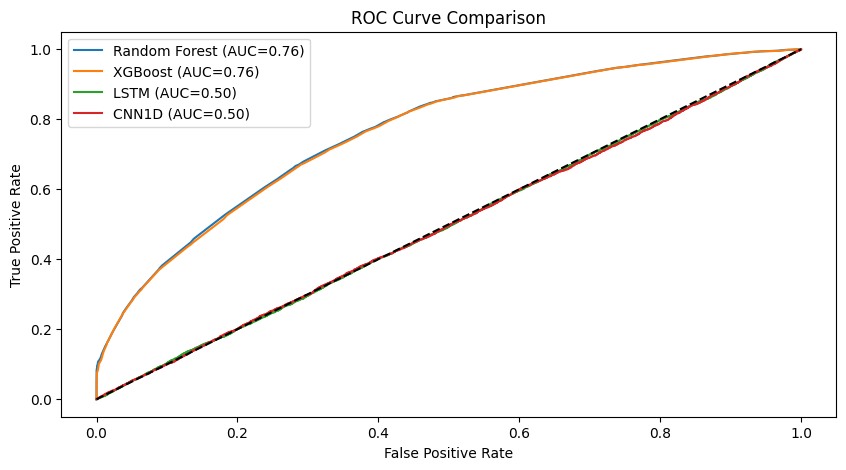

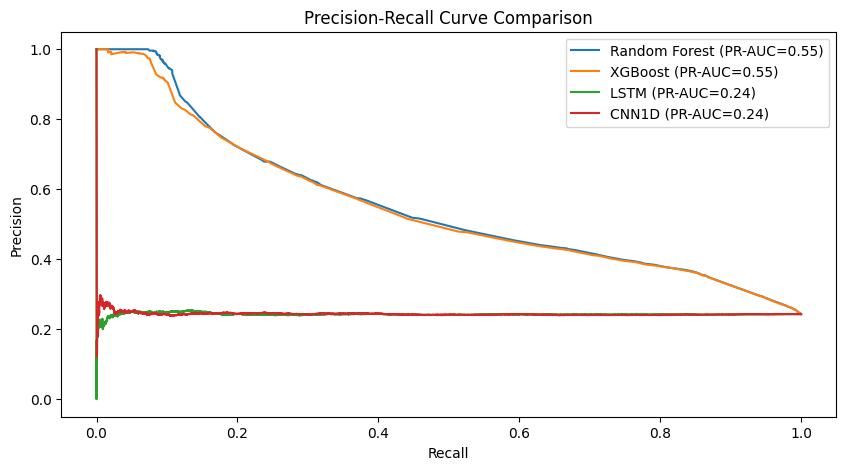

In [110]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

models = {
    'Random Forest': y_proba_rf,
    'XGBoost': y_proba_xgb,
    'LSTM': y_proba_lstm,
    'CNN1D': y_proba_cnn
}

plt.figure(figsize=(10,5))
for name, y_proba in models.items():
    fpr, tpr, _ = roc_curve(y_test_seq if 'LSTM' in name or 'CNN' in name else y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test_seq if 'LSTM' in name or 'CNN' in name else y_test, y_proba):.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# PR-AUC
plt.figure(figsize=(10,5))
for name, y_proba in models.items():
    precision, recall, _ = precision_recall_curve(y_test_seq if 'LSTM' in name or 'CNN' in name else y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (PR-AUC={auc(recall, precision):.2f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()


<h1 style="color: red;">Phase 5&nbsp;: ÉVALUATION & RAPPORT</h1> 

<H3>1 Génération des métriques (modèle retenu : Random Forest / XGBoost)</H3>

👉 On prend Random Forest comme modèle principal (robuste + explicable).

In [111]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

# Prédictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Rapport de classification
print("===== Classification Report =====")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC :", roc_auc)

# PR-AUC
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print("PR-AUC :", pr_auc)


===== Classification Report =====
              precision    recall  f1-score   support

           0       0.89      0.62      0.73     20226
           1       0.39      0.77      0.52      6502

    accuracy                           0.65     26728
   macro avg       0.64      0.69      0.62     26728
weighted avg       0.77      0.65      0.68     26728

ROC-AUC : 0.7637841384967522
PR-AUC : 0.5543115145126891


<H3>2 Visualisations</H3>

<H5>🔹 Matrice de confusion</H5>

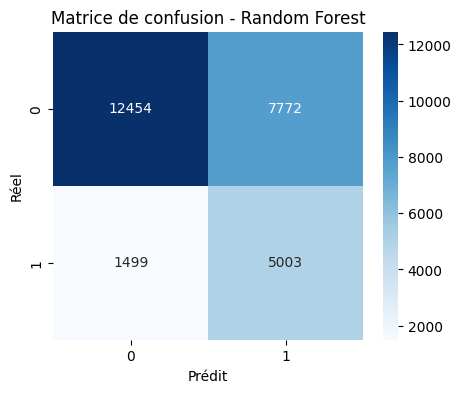

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Random Forest")
plt.show()


<H5>🔹 Courbe ROC</H5>

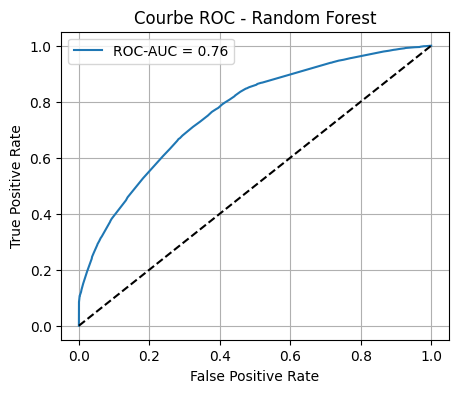

In [113]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Random Forest")
plt.legend()
plt.grid(True)
plt.show()


<H5>🔹 Courbe Precision-Recall</H5>

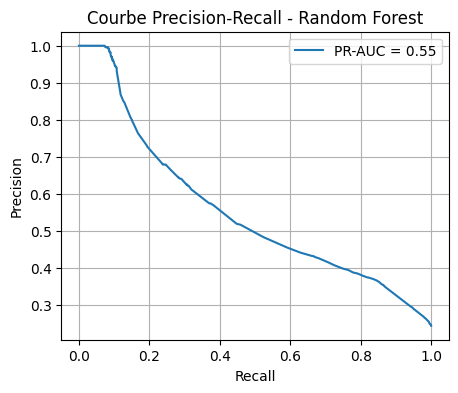

In [114]:
plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe Precision-Recall - Random Forest")
plt.legend()
plt.grid(True)
plt.show()


<H3>3 Analyse des erreurs</H3>

In [115]:
import numpy as np

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("Faux Positifs (FP) :", FP)
print("Faux Négatifs (FN) :", FN)


Faux Positifs (FP) : 7772
Faux Négatifs (FN) : 1499


<B>Limites identifiées</B>

Déséquilibre des classes

Fenêtres fixes (1s)

Pas de payload réseau brut

MQTT uniquement (pas TCP flags réels)

<H5>Améliorations proposées</H5>

🔧 Améliorations ML

class_weight='balanced'

Seuil de décision ajustable

Ensemble RF + XGB

🧠 Deep Learning

LSTM pour patterns temporels longs

CNN 1D pour bursts locaux

🌐 Réseau

Ajout PCAP (TCP flags, ports)

Flow-based features

Fenêtres adaptatives